In [1]:
# =============================================================================
# 1. IMPORTACIÓN DE LIBRERÍAS
# =============================================================================

from pathlib import Path
import warnings
import re
import unicodedata

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 120)

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["figure.dpi"] = 120

In [4]:
# =============================================================================
# 2. CONFIGURACIÓN DE RUTAS
# =============================================================================

# El notebook está dentro de:
# scripts/Exploración de los datos
#
# Por tanto, subimos dos niveles para llegar a la raíz del proyecto TFM_github.

BASE_PATH = Path("..", "..")

FOLDER_DATA = BASE_PATH / "datasets" / "archivo_ciudades"
FOLDER_OUTPUT = BASE_PATH / "datasets" / "eda_archivo_ciudades"
FOLDER_FIGS = BASE_PATH / "figuras" / "EDA2"

RUTA_CIUDADES = FOLDER_DATA / "ciudades.csv"

FOLDER_OUTPUT.mkdir(parents=True, exist_ok=True)
FOLDER_FIGS.mkdir(parents=True, exist_ok=True)

print("Ruta base del proyecto:")
print(BASE_PATH.resolve())

print("\nRuta del CSV de ciudades:")
print(RUTA_CIUDADES.resolve())

print("\nRuta de salida:")
print(FOLDER_OUTPUT.resolve())

print("\nRuta de figuras:")
print(FOLDER_FIGS.resolve())

Ruta base del proyecto:
C:\Users\Juanfran cd\Desktop\Máster_Ciencia_de_Datos_UA\TFM\TFM_github

Ruta del CSV de ciudades:
C:\Users\Juanfran cd\Desktop\Máster_Ciencia_de_Datos_UA\TFM\TFM_github\datasets\archivo_ciudades\ciudades.csv

Ruta de salida:
C:\Users\Juanfran cd\Desktop\Máster_Ciencia_de_Datos_UA\TFM\TFM_github\datasets\eda_archivo_ciudades

Ruta de figuras:
C:\Users\Juanfran cd\Desktop\Máster_Ciencia_de_Datos_UA\TFM\TFM_github\figuras\EDA2


In [5]:
# =============================================================================
# 3. FUNCIONES AUXILIARES
# =============================================================================

def normalizar_texto(texto):
    """
    Normaliza texto para nombres de columnas, archivos y comparaciones.
    """

    texto = str(texto)

    texto = unicodedata.normalize("NFKD", texto)
    texto = "".join(c for c in texto if not unicodedata.combining(c))

    texto = texto.replace("µ", "u").replace("μ", "u")
    texto = texto.lower()

    texto = re.sub(r"[^a-z0-9]+", "_", texto)
    texto = re.sub(r"_+", "_", texto).strip("_")

    return texto


def leer_csv_robusto(ruta):
    """
    Lee un CSV intentando detectar automáticamente el separador.
    """

    try:
        return pd.read_csv(
            ruta,
            sep=None,
            engine="python",
            encoding="utf-8-sig"
        )

    except Exception:
        try:
            return pd.read_csv(
                ruta,
                sep=";",
                encoding="utf-8-sig"
            )

        except Exception:
            return pd.read_csv(
                ruta,
                sep=",",
                encoding="utf-8-sig"
            )

In [6]:
# =============================================================================
# 4. CARGA E INSPECCIÓN DEL DATASET
# =============================================================================

df_ciudades = leer_csv_robusto(RUTA_CIUDADES)

print("Dataset cargado correctamente.")
print(f"Número de filas: {df_ciudades.shape[0]}")
print(f"Número de columnas: {df_ciudades.shape[1]}")

display(df_ciudades)
display(df_ciudades.info())

Dataset cargado correctamente.
Número de filas: 12
Número de columnas: 7


,Ciudad,Latitud,Longitud,Altitud (m),Superficie (km²),Distancia_Mar (km),TPI_Factor_Cuenca
0,Madrid,4.041.694,-370.33300,660.0,604.45,327.66,14.10
1,Barcelona,413.825,217.69400,30.0,101.35,2.60,-48.24
2,Bilbao,4.326.306,-2.93500,24.0,41.60,8.75,-150.72
3,Sevilla,3.738.861,-599.55600,17.0,141.42,53.66,-21.20
4,Valencia,39.47,-0.37639,23.0,134.65,3.99,-1.72
5,Valladolid,4.165.198,-472.85600,704.0,197.91,193.42,-50.06
6,Murcia,3.798.333,-113.02800,56.0,881.86,35.41,-145.54
7,Santa Cruz de Tenerife,2.846.667,-16.25000,34.0,150.56,0.47,-237.02
8,A Coruña,4.337.386,-840.00300,21.0,37.83,1.06,-5.36
9,Zaragoza,41.65,-0.88333,224.0,973.78,169.66,-191.62


<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Ciudad              12 non-null     str    
 1   Latitud             12 non-null     str    
 2   Longitud            12 non-null     float64
 3   Altitud (m)         12 non-null     float64
 4   Superficie (km²)    12 non-null     float64
 5   Distancia_Mar (km)  12 non-null     float64
 6   TPI_Factor_Cuenca   12 non-null     float64
dtypes: float64(5), str(2)
memory usage: 1017.0 bytes


None

In [7]:
# =============================================================================
# 5. DETECCIÓN DE VARIABLES PARA CLUSTERING
# =============================================================================

# Buscamos automáticamente la columna que identifica la ciudad.
posibles_columnas_ciudad = [
    "city", "Ciudad", "ciudad", "Municipio", "municipio", "nombre", "Nombre"
]

col_ciudad = None

for col in posibles_columnas_ciudad:
    if col in df_ciudades.columns:
        col_ciudad = col
        break

if col_ciudad is None:
    raise ValueError(
        "No se ha encontrado una columna clara de ciudad. "
        "Revisa el nombre de la columna identificadora."
    )

print(f"Columna identificadora de ciudad detectada: {col_ciudad}")


# -----------------------------------------------------------------------------
# Variables numéricas candidatas para clustering
# -----------------------------------------------------------------------------

columnas_numericas = [
    col for col in df_ciudades.columns
    if col != col_ciudad
    and pd.api.types.is_numeric_dtype(df_ciudades[col])
]

print("\nVariables numéricas disponibles para clustering:")
display(pd.DataFrame({"Variable": columnas_numericas}))


# Comprobación.
if len(columnas_numericas) < 2:
    raise ValueError(
        "Hay menos de dos variables numéricas para clustering. "
        "Revisa el CSV o convierte las columnas necesarias a formato numérico."
    )

Columna identificadora de ciudad detectada: Ciudad

Variables numéricas disponibles para clustering:


,Variable
0,Longitud
1,Altitud (m)
2,Superficie (km²)
3,Distancia_Mar (km)
4,TPI_Factor_Cuenca


In [8]:
# =============================================================================
# 6. PREPARACIÓN DE DATOS PARA CLUSTERING
# =============================================================================

df_modelo = df_ciudades[[col_ciudad] + columnas_numericas].copy()

# Convertimos las variables numéricas por seguridad.
for col in columnas_numericas:
    df_modelo[col] = pd.to_numeric(df_modelo[col], errors="coerce")


# -----------------------------------------------------------------------------
# Imputación de valores ausentes
# -----------------------------------------------------------------------------

imputador = SimpleImputer(strategy="median")

X_imputado = imputador.fit_transform(df_modelo[columnas_numericas])


# -----------------------------------------------------------------------------
# Estandarización
# -----------------------------------------------------------------------------

escalador = StandardScaler()

X_scaled = escalador.fit_transform(X_imputado)

print("Datos preparados para clustering.")
print(f"Número de ciudades: {X_scaled.shape[0]}")
print(f"Número de variables utilizadas: {X_scaled.shape[1]}")

Datos preparados para clustering.
Número de ciudades: 12
Número de variables utilizadas: 5


In [9]:
# =============================================================================
# 7. EVALUACIÓN DEL NÚMERO DE CLUSTERS
# =============================================================================

# Como el usuario quiere como máximo 4 grupos, evaluamos k = 2, 3 y 4.
# Si hay pocas ciudades, se ajusta automáticamente el máximo posible.

k_min = 2
k_max = min(4, X_scaled.shape[0] - 1)

resultados_clusters = []

for k in range(k_min, k_max + 1):

    modelo_kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=50
    )

    labels = modelo_kmeans.fit_predict(X_scaled)

    silhouette = silhouette_score(X_scaled, labels)
    calinski = calinski_harabasz_score(X_scaled, labels)
    davies = davies_bouldin_score(X_scaled, labels)
    inertia = modelo_kmeans.inertia_

    resultados_clusters.append({
        "k": k,
        "silhouette_score": silhouette,
        "calinski_harabasz": calinski,
        "davies_bouldin": davies,
        "inertia": inertia
    })


df_resultados_clusters = pd.DataFrame(resultados_clusters)

display(df_resultados_clusters)

,k,silhouette_score,calinski_harabasz,davies_bouldin,inertia
0,2,0.335839,7.035607,1.094397,35.220347
1,3,0.357986,7.000553,0.798119,23.477132
2,4,0.407908,8.817201,0.732547,13.932589


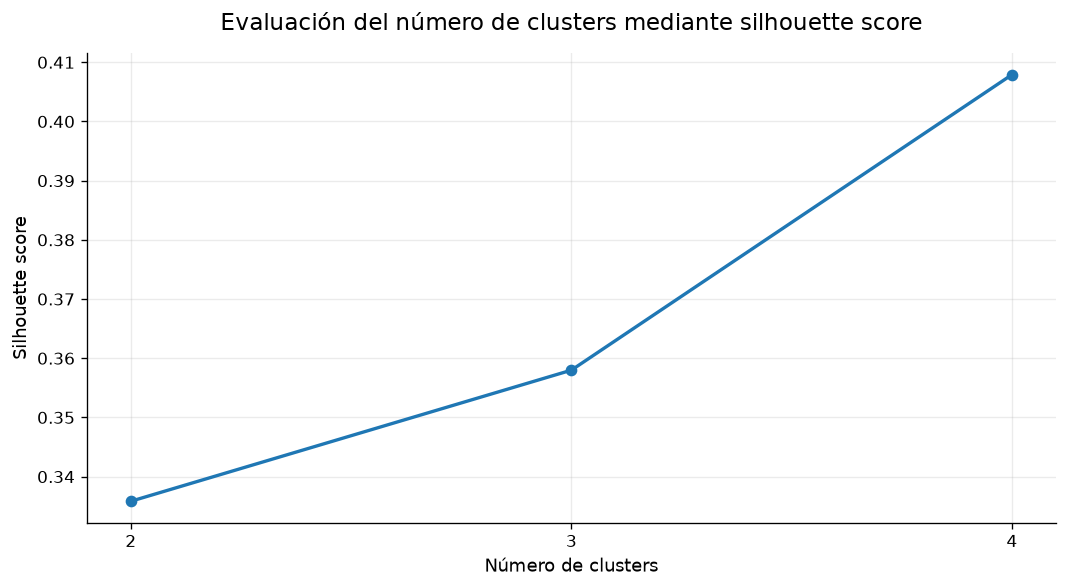

In [10]:
# =============================================================================
# 8. VISUALIZACIÓN DE MÉTRICAS DE CLUSTERING
# =============================================================================

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor("white")

ax.plot(
    df_resultados_clusters["k"],
    df_resultados_clusters["silhouette_score"],
    marker="o",
    linewidth=2
)

ax.set_title("Evaluación del número de clusters mediante silhouette score", fontsize=14, pad=14)
ax.set_xlabel("Número de clusters", fontsize=11)
ax.set_ylabel("Silhouette score", fontsize=11)

ax.set_xticks(df_resultados_clusters["k"])

ax.grid(True, alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    FOLDER_FIGS / "evaluacion_k_silhouette.png",
    bbox_inches="tight",
    dpi=180,
    facecolor="white"
)

plt.show()

In [12]:
# =============================================================================
# 9. SELECCIÓN DEL NÚMERO FINAL DE CLUSTERS
# =============================================================================

# Seleccionamos el k con mayor silhouette score.
# En caso de empate, se quedará con el menor número de clusters.

k_optimo = (
    df_resultados_clusters
    .sort_values(["silhouette_score", "k"], ascending=[False, True])
    .iloc[0]["k"]
)

k_optimo = int(k_optimo)

print(f"Número de clusters seleccionado: {k_optimo}")

Número de clusters seleccionado: 4


In [13]:
# =============================================================================
# 10. CLUSTERING FINAL CON KMEANS
# =============================================================================

modelo_final = KMeans(
    n_clusters=k_optimo,
    random_state=42,
    n_init=50
)

labels_finales = modelo_final.fit_predict(X_scaled)

df_clusters = df_ciudades.copy()
df_clusters["cluster"] = labels_finales + 1

display(
    df_clusters
    .sort_values("cluster")
    .reset_index(drop=True)
)

print("Número de ciudades por cluster:")
display(df_clusters["cluster"].value_counts().sort_index())

,Ciudad,Latitud,Longitud,Altitud (m),Superficie (km²),Distancia_Mar (km),TPI_Factor_Cuenca,cluster
0,Murcia,3.798.333,-113.02800,56.0,881.86,35.41,-145.54,1
1,Zaragoza,41.65,-0.88333,224.0,973.78,169.66,-191.62,1
2,Albacete,3.899.556,-185.58300,690.0,1125.91,141.70,-81.42,1
3,Barcelona,413.825,217.69400,30.0,101.35,2.60,-48.24,2
4,Santa Cruz de Tenerife,2.846.667,-16.25000,34.0,150.56,0.47,-237.02,2
5,Alicante/Alacant,3.834.528,-0.48306,21.0,201.27,0.90,-54.72,2
6,Valencia,39.47,-0.37639,23.0,134.65,3.99,-1.72,2
7,Bilbao,4.326.306,-2.93500,24.0,41.60,8.75,-150.72,2
8,Sevilla,3.738.861,-599.55600,17.0,141.42,53.66,-21.20,3
9,A Coruña,4.337.386,-840.00300,21.0,37.83,1.06,-5.36,3


Número de ciudades por cluster:


cluster
1    3
2    5
3    2
4    2
Name: count, dtype: int64

In [14]:
# =============================================================================
# 11. RESUMEN DE CIUDADES POR CLUSTER
# =============================================================================

resumen_clusters = (
    df_clusters
    .groupby("cluster")[col_ciudad]
    .apply(lambda x: ", ".join(x.astype(str)))
    .reset_index()
    .rename(columns={col_ciudad: "Ciudades"})
)

display(resumen_clusters)

,cluster,Ciudades
0,1,"Murcia, Zaragoza, Albacete"
1,2,"Barcelona, Bilbao, Valencia, Santa Cruz de Tenerife, Alicante/Alacant"
2,3,"Sevilla, A Coruña"
3,4,"Madrid, Valladolid"


In [15]:
# =============================================================================
# 12. PERFIL MEDIO DE CADA CLUSTER
# =============================================================================

perfil_clusters = (
    df_clusters
    .groupby("cluster")[columnas_numericas]
    .mean()
    .round(3)
)

display(perfil_clusters)

,Longitud,Altitud (m),Superficie (km²),Distancia_Mar (km),TPI_Factor_Cuenca
cluster,,,,,
1,-99.831,323.333,993.850,115.590,-139.527
2,39.530,26.400,125.886,3.342,-98.484
3,-719.780,19.000,89.625,27.360,-13.280
4,-421.595,682.000,401.180,260.540,-17.980


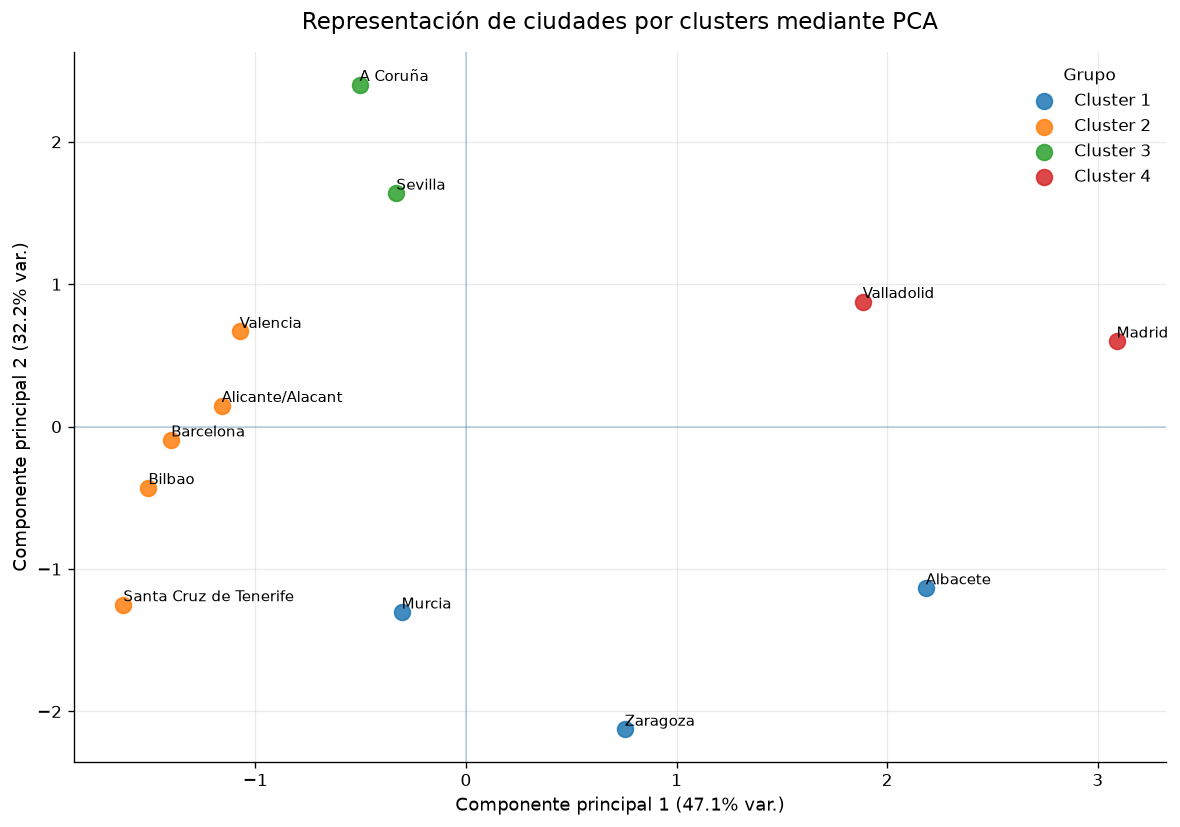

In [16]:
# =============================================================================
# 13. REPRESENTACIÓN DE CLUSTERS MEDIANTE PCA
# =============================================================================

pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "cluster": df_clusters["cluster"],
    col_ciudad: df_clusters[col_ciudad]
})

varianza_pc1 = pca.explained_variance_ratio_[0] * 100
varianza_pc2 = pca.explained_variance_ratio_[1] * 100


fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor("white")

for cluster in sorted(df_pca["cluster"].unique()):

    df_cluster = df_pca[df_pca["cluster"] == cluster]

    ax.scatter(
        df_cluster["PC1"],
        df_cluster["PC2"],
        s=90,
        label=f"Cluster {cluster}",
        alpha=0.85
    )

    for _, fila in df_cluster.iterrows():
        ax.text(
            fila["PC1"],
            fila["PC2"],
            str(fila[col_ciudad]),
            fontsize=9,
            ha="left",
            va="bottom"
        )

ax.axhline(0, linewidth=1, alpha=0.3)
ax.axvline(0, linewidth=1, alpha=0.3)

ax.set_title("Representación de ciudades por clusters mediante PCA", fontsize=14, pad=14)
ax.set_xlabel(f"Componente principal 1 ({varianza_pc1:.1f}% var.)", fontsize=11)
ax.set_ylabel(f"Componente principal 2 ({varianza_pc2:.1f}% var.)", fontsize=11)

ax.legend(title="Grupo", frameon=False)

ax.grid(True, alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    FOLDER_FIGS / "clusters_ciudades_pca.png",
    bbox_inches="tight",
    dpi=180,
    facecolor="white"
)

plt.show()